# Import Library (Menyiapkan Library)
## Mengimport library python yang akan di pakai seperti:
### - Pandas : untuk membaca data menjadi data tabular, memanipulasi data, pembersihan data dll
### - Numpy : untuk memperoses data numeric dan manipulasi array dengan efisien
### - Matplotlib & Seaborn : untuk memvisualisasikan data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import scipy.stats as stat


## Menyimpan dan mengubah bentuk data berbentuk CSV ke DataFrame ke variabel df serta mencari informasi terkait dataset

In [19]:
df = pd.read_csv('../data/raw/jakarta_properties_baru_fixed.csv')

In [20]:
df.sample()

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at
23310,Rumah Citra Garden 2 Lokasi Strategis 2 Lantai...,3.400000e+09,Jakarta Barat,Citra Garden,5.0,5.0,1.0,160.0,210.0,2026-05-20T19:17:31.193808+00:00


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49953 entries, 0 to 49952
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             49953 non-null  str    
 1   price_idr         49953 non-null  float64
 2   city              49953 non-null  str    
 3   district          49953 non-null  str    
 4   bedrooms          48757 non-null  float64
 5   bathrooms         48787 non-null  float64
 6   garage            38587 non-null  float64
 7   land_size_m2      49930 non-null  float64
 8   building_size_m2  49874 non-null  float64
 9   scraped_at        49953 non-null  str    
dtypes: float64(6), str(4)
memory usage: 3.8 MB


In [22]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,4.995300e+04,48757.000000,48787.000000,38587.000000,49930.000000,49874.000000
mean,1.130787e+10,5.052259,4.078402,2.869697,300.438594,335.734050
std,2.161632e+10,7.965665,3.915385,2.475343,436.796303,935.441777
min,7.950000e+06,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.550000e+09,3.000000,3.000000,1.000000,108.000000,148.000000
50%,4.700000e+09,4.000000,4.000000,2.000000,183.000000,240.000000
75%,1.000000e+10,6.000000,5.000000,4.000000,350.000000,400.000000
max,9.000000e+11,1314.000000,292.000000,70.000000,21754.000000,116799.000000


# Data Cleaning & Ubah type data
## Mengisi nilai di kolom garasi yang nan atau kosong jadi 0 & Mengubah Dtype kolom "price_idr" menjadi numeric lalu memfilter harga harus di atas 0

In [23]:
# Mengisi nilai nan atau null dengan 0
df['garage'] = df['garage'].fillna(0)

# Mengubah type data kolom "price_idr" menjadi numeric
df['price_idr'] = pd.to_numeric(df['price_idr'], errors='coerce')

# Memfilter agar setiap baris wajib memiliki harga
df = df[(df['price_idr'] > 0) & (df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

df = df[(df['building_size_m2'] >= 30) & (df['land_size_m2'] >= 30 )]

map_col = ['bedrooms','bathrooms','garage']

for col in map_col:
    df = df[(df[col] != df['land_size_m2']) & (df[col] != df['building_size_m2'])]

In [24]:
# Menghapus baris yang ada missing value di salah satu kolom 
df = df.dropna(axis=0) # (axis=0 untuk target baris, axis=1 untuk target kolom)

In [25]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,4.810600e+04,48106.000000,48106.000000,48106.000000,48106.000000,48106.000000
mean,1.113516e+10,5.043550,4.085332,2.271650,297.890346,336.314306
std,2.085302e+10,7.198733,3.597660,2.467121,422.703908,948.128371
min,5.000000e+07,1.000000,1.000000,0.000000,30.000000,30.000000
25%,2.600000e+09,4.000000,3.000000,1.000000,108.000000,150.000000
50%,4.700000e+09,4.000000,4.000000,2.000000,182.000000,240.000000
75%,1.000000e+10,6.000000,5.000000,3.000000,350.000000,400.000000
max,6.000000e+11,1314.000000,292.000000,70.000000,21754.000000,116799.000000


## Mencari tau sebaran data di kolom "price_idr" & Mencari Outlier

In [26]:
sns.set()

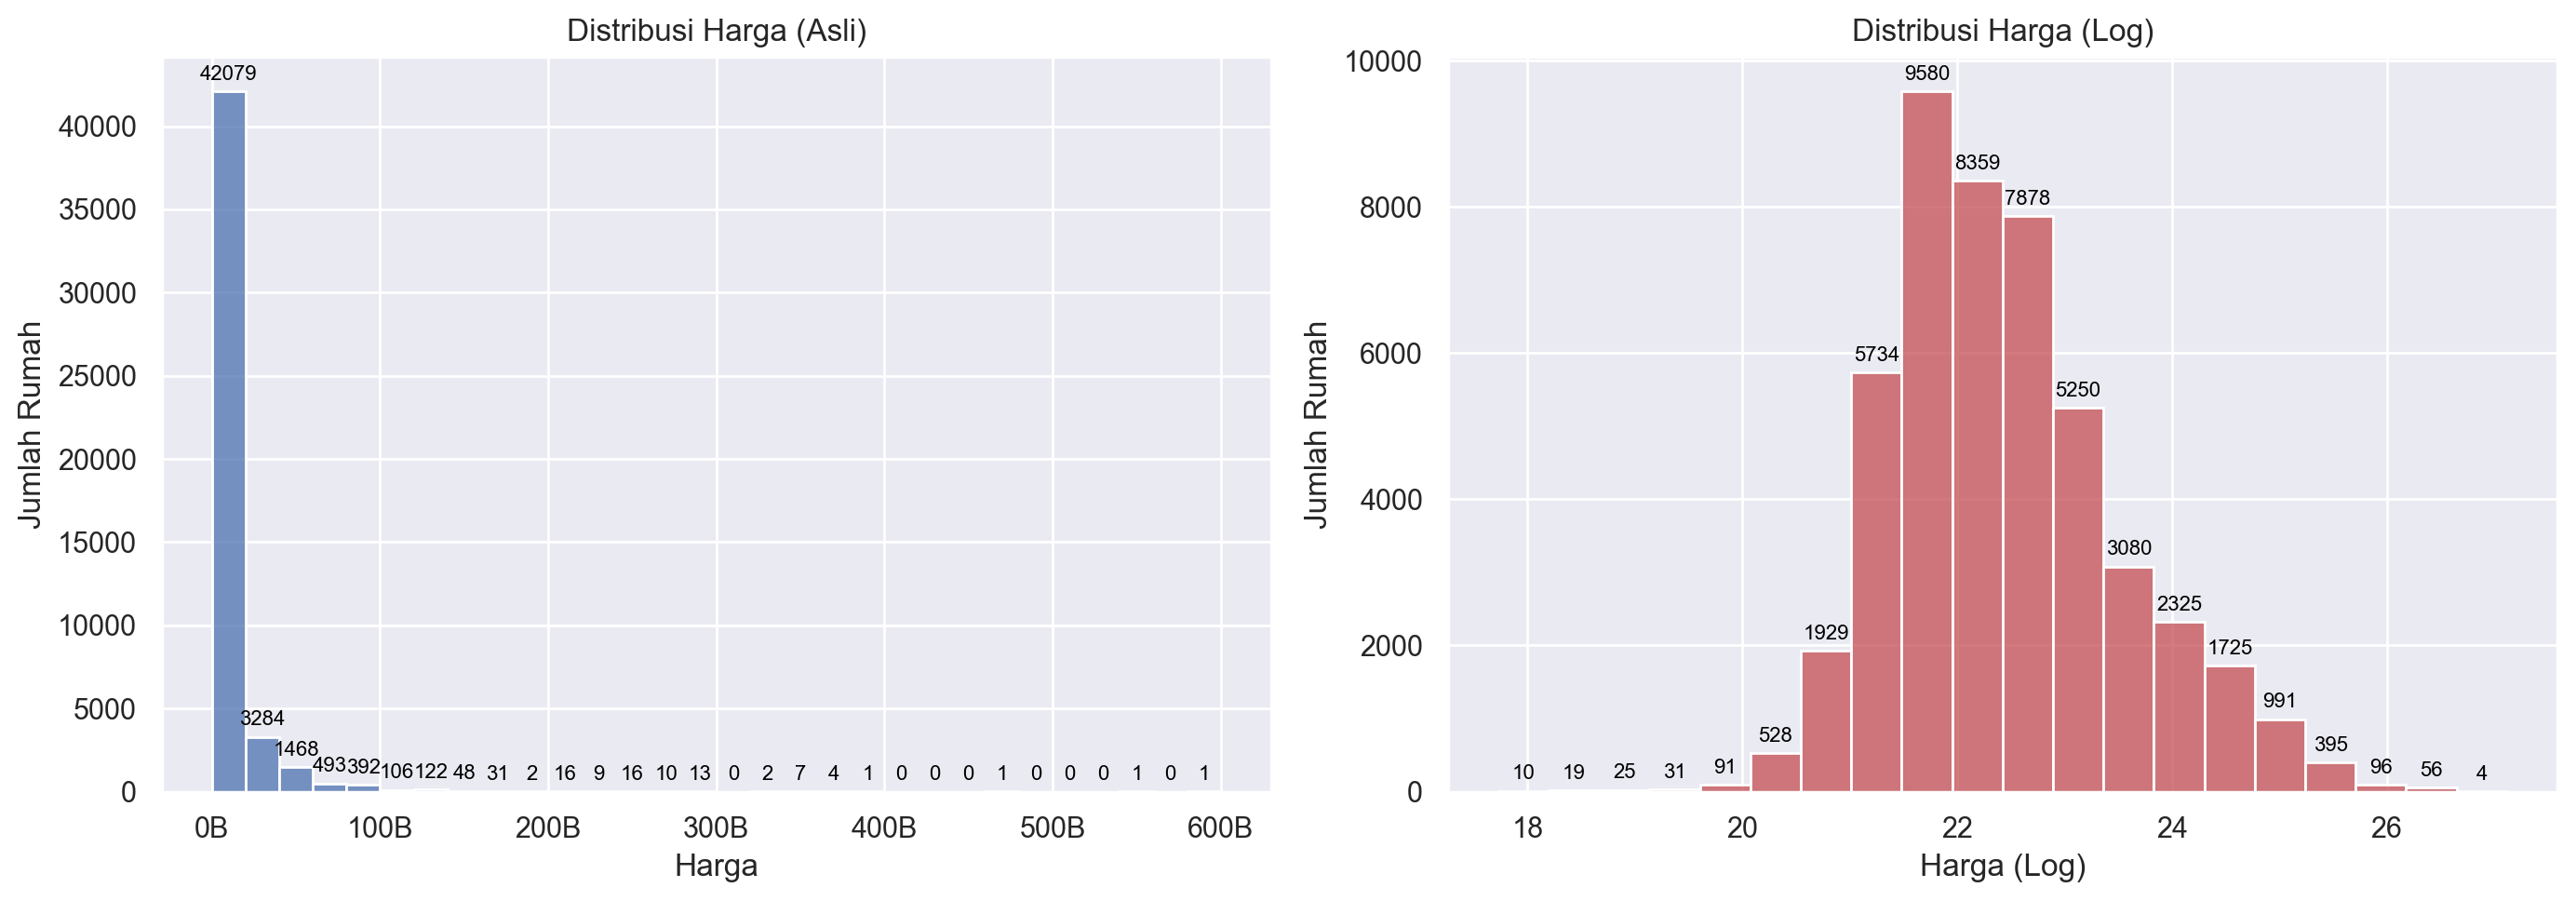

In [27]:
# Membuat figure dengan 1 baris 2 kolom dengan lebar 12 dan tinggi 5
fig , axes = plt.subplots(1,2,figsize=(14,5),dpi=200)

# Membuat axes pertama untuk menampilkan distribusi dengan nilai asli
sns.histplot(df['price_idr'],bins=30,color='b',ax=axes[0])
axes[0].bar_label(axes[0].containers[0],fontsize=8,color='black',padding=3)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
axes[0].set_title('Distribusi Harga (Asli)')
axes[0].set_xlabel('Harga')
axes[0].set_ylabel('Jumlah Rumah')

# Membuat axes kedua untuk menampilkan distribusi dengan nilai log
sns.histplot(np.log1p(df['price_idr']),bins=20,color='r',ax=axes[1])
axes[1].bar_label(axes[1].containers[0],fontsize=8,color='black',padding=3)
axes[1].set_title('Distribusi Harga (Log)')
axes[1].set_xlabel('Harga (Log)')
axes[1].set_ylabel('Jumlah Rumah')

# Memberi jarak terhadap axes
fig.tight_layout()
plt.show()

### Mencari outliers menggunakan IQR (interquartile range) karena data harga asli right-skew atau tidak terdistribusi dengan normal untuk keperluan EDA

In [29]:
Q1 = df['price_idr'].quantile(0.25)
Q3 = df['price_idr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price_idr'] < lower) | (df['price_idr'] > upper)]
outliers_high = df[df['price_idr'] > upper]
outliers_low = df[df['price_idr'] < lower]
print(f'Batas Bawah: {lower}')
print(f'Batas Atas: {upper}')
print(f'Jumlah Total Outlier: {len(outliers)}')
print(f'Jumlah Outlier Di Bawah Batas Bawah: {len(outliers_low)}') 
print(f'Jumlah Outlier Di Atas Batas Atas: {len(outliers_high)}') 

Batas Bawah: -8500000000.0
Batas Atas: 21100000000.0
Jumlah Total Outlier: 5822
Jumlah Outlier Di Bawah Batas Bawah: 0
Jumlah Outlier Di Atas Batas Atas: 5822


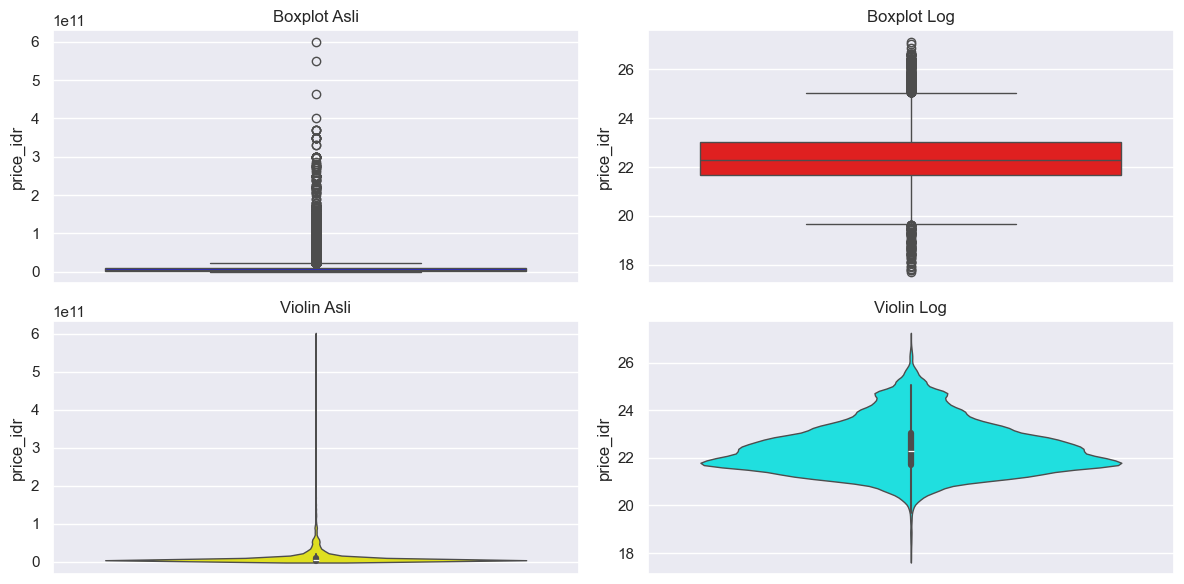

In [30]:

fig , ax = plt.subplots(2,2,figsize=(12,6))

sns.boxplot(y=df['price_idr'],ax=ax[0,0],color='blue')
ax[0,0].set_title('Boxplot Asli')

sns.boxplot(y=np.log1p(df['price_idr']),ax=ax[0,1],color='red')
ax[0,1].set_title('Boxplot Log')

sns.violinplot(y=df['price_idr'],ax=ax[1,0],bw_adjust=1, cut=1, linewidth=1,color='yellow')
ax[1,0].set_title('Violin Asli')

sns.violinplot(y=np.log1p(df['price_idr']),ax=ax[1,1],cut=1, linewidth=1,color='cyan')
ax[1,1].set_title('Violin Log')

plt.tight_layout()
plt.show()

## Insight Visualisasi Boxplot & Violin:
### Nilai Asli : Menunjukan kepadatan harga di antara 0-50M
### Nilai Log : Menunjukan sebaran harga terdistribusi dengan normal dan tidak menumpuk

## Mencari informasi data yang outliers

In [31]:
outliers.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,5.822000e+03,5822.000000,5822.000000,5822.000000,5822.000000,5822.000000
mean,5.150807e+10,6.978873,5.862590,4.900034,886.613535,870.529371
std,3.995269e+10,6.499724,6.275747,4.411761,878.320794,2607.395356
min,2.120000e+10,1.000000,1.000000,0.000000,75.000000,30.000000
25%,2.800000e+10,5.000000,4.000000,2.000000,550.000000,482.000000
50%,3.900000e+10,6.000000,5.000000,4.000000,720.000000,650.000000
75%,5.800000e+10,7.000000,6.000000,7.000000,984.000000,1000.000000
max,6.000000e+11,121.000000,292.000000,70.000000,21754.000000,116799.000000


In [33]:
na = df[(df['price_idr'] > 50_000_000_000) & ((df['land_size_m2'] < 100) | (df['building_size_m2'] < 100))]
na

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at
46519,Tanah Komersil Siapbangun 8 Lantai Jl Wahid Ha...,1.260000e+11,Jakarta Pusat,Wahid Hasyim,1.0,1.0,2.0,1012.0,30.0,2026-05-21T20:46:31.311911+00:00
49241,Rumah Klasik Di Menteng Jakpus,6.900000e+10,Jakarta Pusat,Menteng,3.0,2.0,2.0,639.0,80.0,2026-05-22T15:18:43.528734+00:00


In [34]:
df.info()

<class 'pandas.DataFrame'>
Index: 48106 entries, 0 to 49952
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             48106 non-null  str    
 1   price_idr         48106 non-null  float64
 2   city              48106 non-null  str    
 3   district          48106 non-null  str    
 4   bedrooms          48106 non-null  float64
 5   bathrooms         48106 non-null  float64
 6   garage            48106 non-null  float64
 7   land_size_m2      48106 non-null  float64
 8   building_size_m2  48106 non-null  float64
 9   scraped_at        48106 non-null  str    
dtypes: float64(6), str(4)
memory usage: 4.0 MB


In [35]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,4.810600e+04,48106.000000,48106.000000,48106.000000,48106.000000,48106.000000
mean,1.113516e+10,5.043550,4.085332,2.271650,297.890346,336.314306
std,2.085302e+10,7.198733,3.597660,2.467121,422.703908,948.128371
min,5.000000e+07,1.000000,1.000000,0.000000,30.000000,30.000000
25%,2.600000e+09,4.000000,3.000000,1.000000,108.000000,150.000000
50%,4.700000e+09,4.000000,4.000000,2.000000,182.000000,240.000000
75%,1.000000e+10,6.000000,5.000000,3.000000,350.000000,400.000000
max,6.000000e+11,1314.000000,292.000000,70.000000,21754.000000,116799.000000


In [36]:
df['title'] = df['title'].str.lower()
df['cluster'] = df['title'].str.contains('cluster', na=False).astype(int)
df['pool'] = df['title'].str.contains(r'kolam renang|pool', na=False).astype(int)
df['mrt'] = df['title'].str.contains(r'mrt', na=False).astype(int)
df['tol'] = df['title'].str.contains(r'tol', na=False).astype(int)
df['furnished'] = df['title'].str.contains(r'furnished', na=False).astype(int)
df['mall'] = df['title'].str.contains(r'mall', na=False).astype(int)
df['kos'] = df['title'].str.contains(r'kos|kost|kostan|kosan', na=False).astype(int)
df['rumah_sakit'] = (df['title'].str.contains(r'rumah sakit', na=False) &~ df['title'].str.contains(r'dekat|near|sekitar|selangkah', na=False)).astype(int)

In [37]:
df[(df['kos'] == 1) | (df['rumah_sakit'] == 1)]

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at,cluster,pool,mrt,tol,furnished,mall,kos,rumah_sakit
3,rumah 2 lantai di tanjung duren utara cocok un...,8.500000e+09,Jakarta Barat,Tanjung Duren Utara,3.0,5.0,9.0,350.0,500.0,2026-04-28T01:42:25.528413+00:00,0,0,0,0,0,0,1,0
162,rumah kost dijual jl madrasah dekat akses mrt ...,8.000000e+09,Jakarta Selatan,Cilandak,15.0,15.0,2.0,344.0,580.0,2026-04-28T01:57:43.387920+00:00,0,0,1,0,0,0,1,0
166,dijual rumah beserta rumah kos dijati padang j...,6.500000e+09,Jakarta Selatan,Jati Padang,14.0,13.0,6.0,600.0,250.0,2026-04-28T01:57:57.992139+00:00,0,0,0,0,0,0,1,0
230,rumah tua masih layak huni terletak di segitig...,3.100000e+10,Jakarta Selatan,Karet,4.0,3.0,4.0,750.0,450.0,2026-04-28T02:01:18.776690+00:00,0,0,0,0,0,0,1,0
252,"rumah kost tebet 10 kamar tidur, fully renovat...",3.900000e+09,Jakarta Selatan,Tebet,9.0,5.0,1.0,126.0,250.0,2026-04-28T02:02:29.491060+00:00,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49813,cocok buat kos atau hunian lokasi tengah kota....,2.400000e+09,Jakarta Pusat,Cempaka Putih,6.0,4.0,6.0,210.0,180.0,2026-05-22T16:05:31.446674+00:00,0,0,0,0,0,0,1,0
49834,rumah hunian kos-kosan dekat fasilitas umum lo...,8.800000e+09,Jakarta Pusat,Cempaka Putih,6.0,4.0,4.0,360.0,600.0,2026-05-22T16:07:27.691859+00:00,0,0,0,0,0,0,1,0
49846,rumah kost 23 kamar lokasi strategis di kramat...,2.300000e+10,Jakarta Pusat,Kramat,23.0,19.0,0.0,624.0,624.0,2026-05-22T16:08:18.423117+00:00,0,0,0,0,0,0,1,0
49848,rumah koskosan 35 kamar di cempaka putih,4.800000e+09,Jakarta Pusat,Cempaka Putih,40.0,13.0,0.0,139.0,500.0,2026-05-22T16:08:31.084162+00:00,0,0,0,0,0,0,1,0


In [38]:
df = df[(df['rumah_sakit'] == 0) & (df['kos'] == 0)]
df = df.drop(columns=['rumah_sakit','kos'])
df.info()

<class 'pandas.DataFrame'>
Index: 46399 entries, 0 to 49952
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             46399 non-null  str    
 1   price_idr         46399 non-null  float64
 2   city              46399 non-null  str    
 3   district          46399 non-null  str    
 4   bedrooms          46399 non-null  float64
 5   bathrooms         46399 non-null  float64
 6   garage            46399 non-null  float64
 7   land_size_m2      46399 non-null  float64
 8   building_size_m2  46399 non-null  float64
 9   scraped_at        46399 non-null  str    
 10  cluster           46399 non-null  int64  
 11  pool              46399 non-null  int64  
 12  mrt               46399 non-null  int64  
 13  tol               46399 non-null  int64  
 14  furnished         46399 non-null  int64  
 15  mall              46399 non-null  int64  
dtypes: float64(6), int64(6), str(4)
memory usage: 6.0 MB


## Melihat Korelasi antar kolom
### Deskripsi:
### 0,00 – 0,25: Korelasi sangat lemah
### 0,25 – 0,50: Korelasi cukup/sedang
### 0,50 – 0,75: Korelasi kuat
### 0,75 – 0,99: Korelasi sangat kuat
### 1,00: Korelasi sempurna
### Note : Korelasi hanya menilai hubungungan antar 2 kolom bukan seluruh kolom, jadi jika korelasi lemah bukan berarti fitur tidak berguna

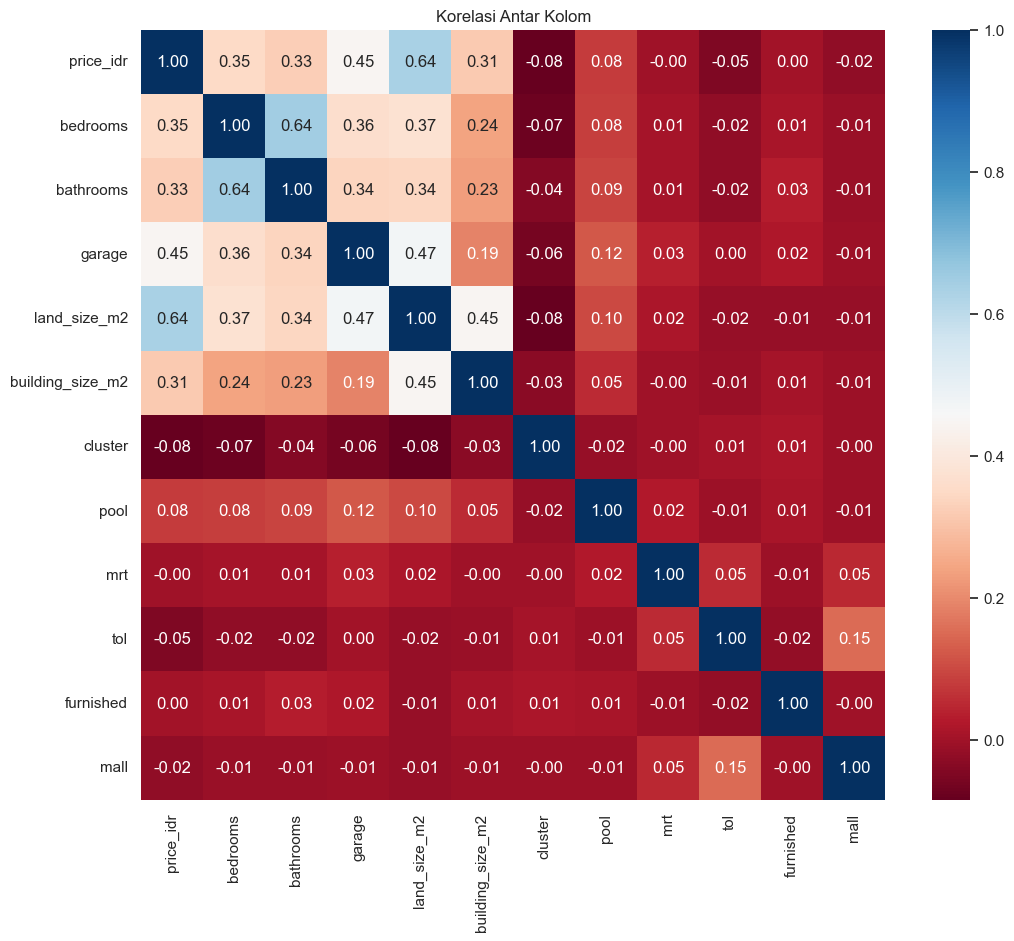

In [39]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='RdBu', fmt='.2f')
plt.title('Korelasi Antar Kolom')
plt.show()

In [40]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,cluster,pool,mrt,tol,furnished,mall
count,4.639900e+04,46399.000000,46399.00000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000
mean,1.124599e+10,4.703463,3.85935,2.272786,298.882347,334.608634,0.066898,0.024850,0.009397,0.028427,0.044117,0.014095
std,2.114190e+10,2.345814,2.45858,2.427492,427.524860,962.416312,0.249848,0.155669,0.096481,0.166192,0.205358,0.117885
min,5.000000e+07,1.000000,1.00000,0.000000,30.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.550000e+09,3.000000,3.00000,1.000000,108.000000,150.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.700000e+09,4.000000,4.00000,2.000000,180.000000,240.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000e+10,5.000000,5.00000,3.000000,350.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6.000000e+11,110.000000,292.00000,70.000000,21754.000000,116799.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Melihat distribusi atau sebaran kolom lain menggunakan histoplot

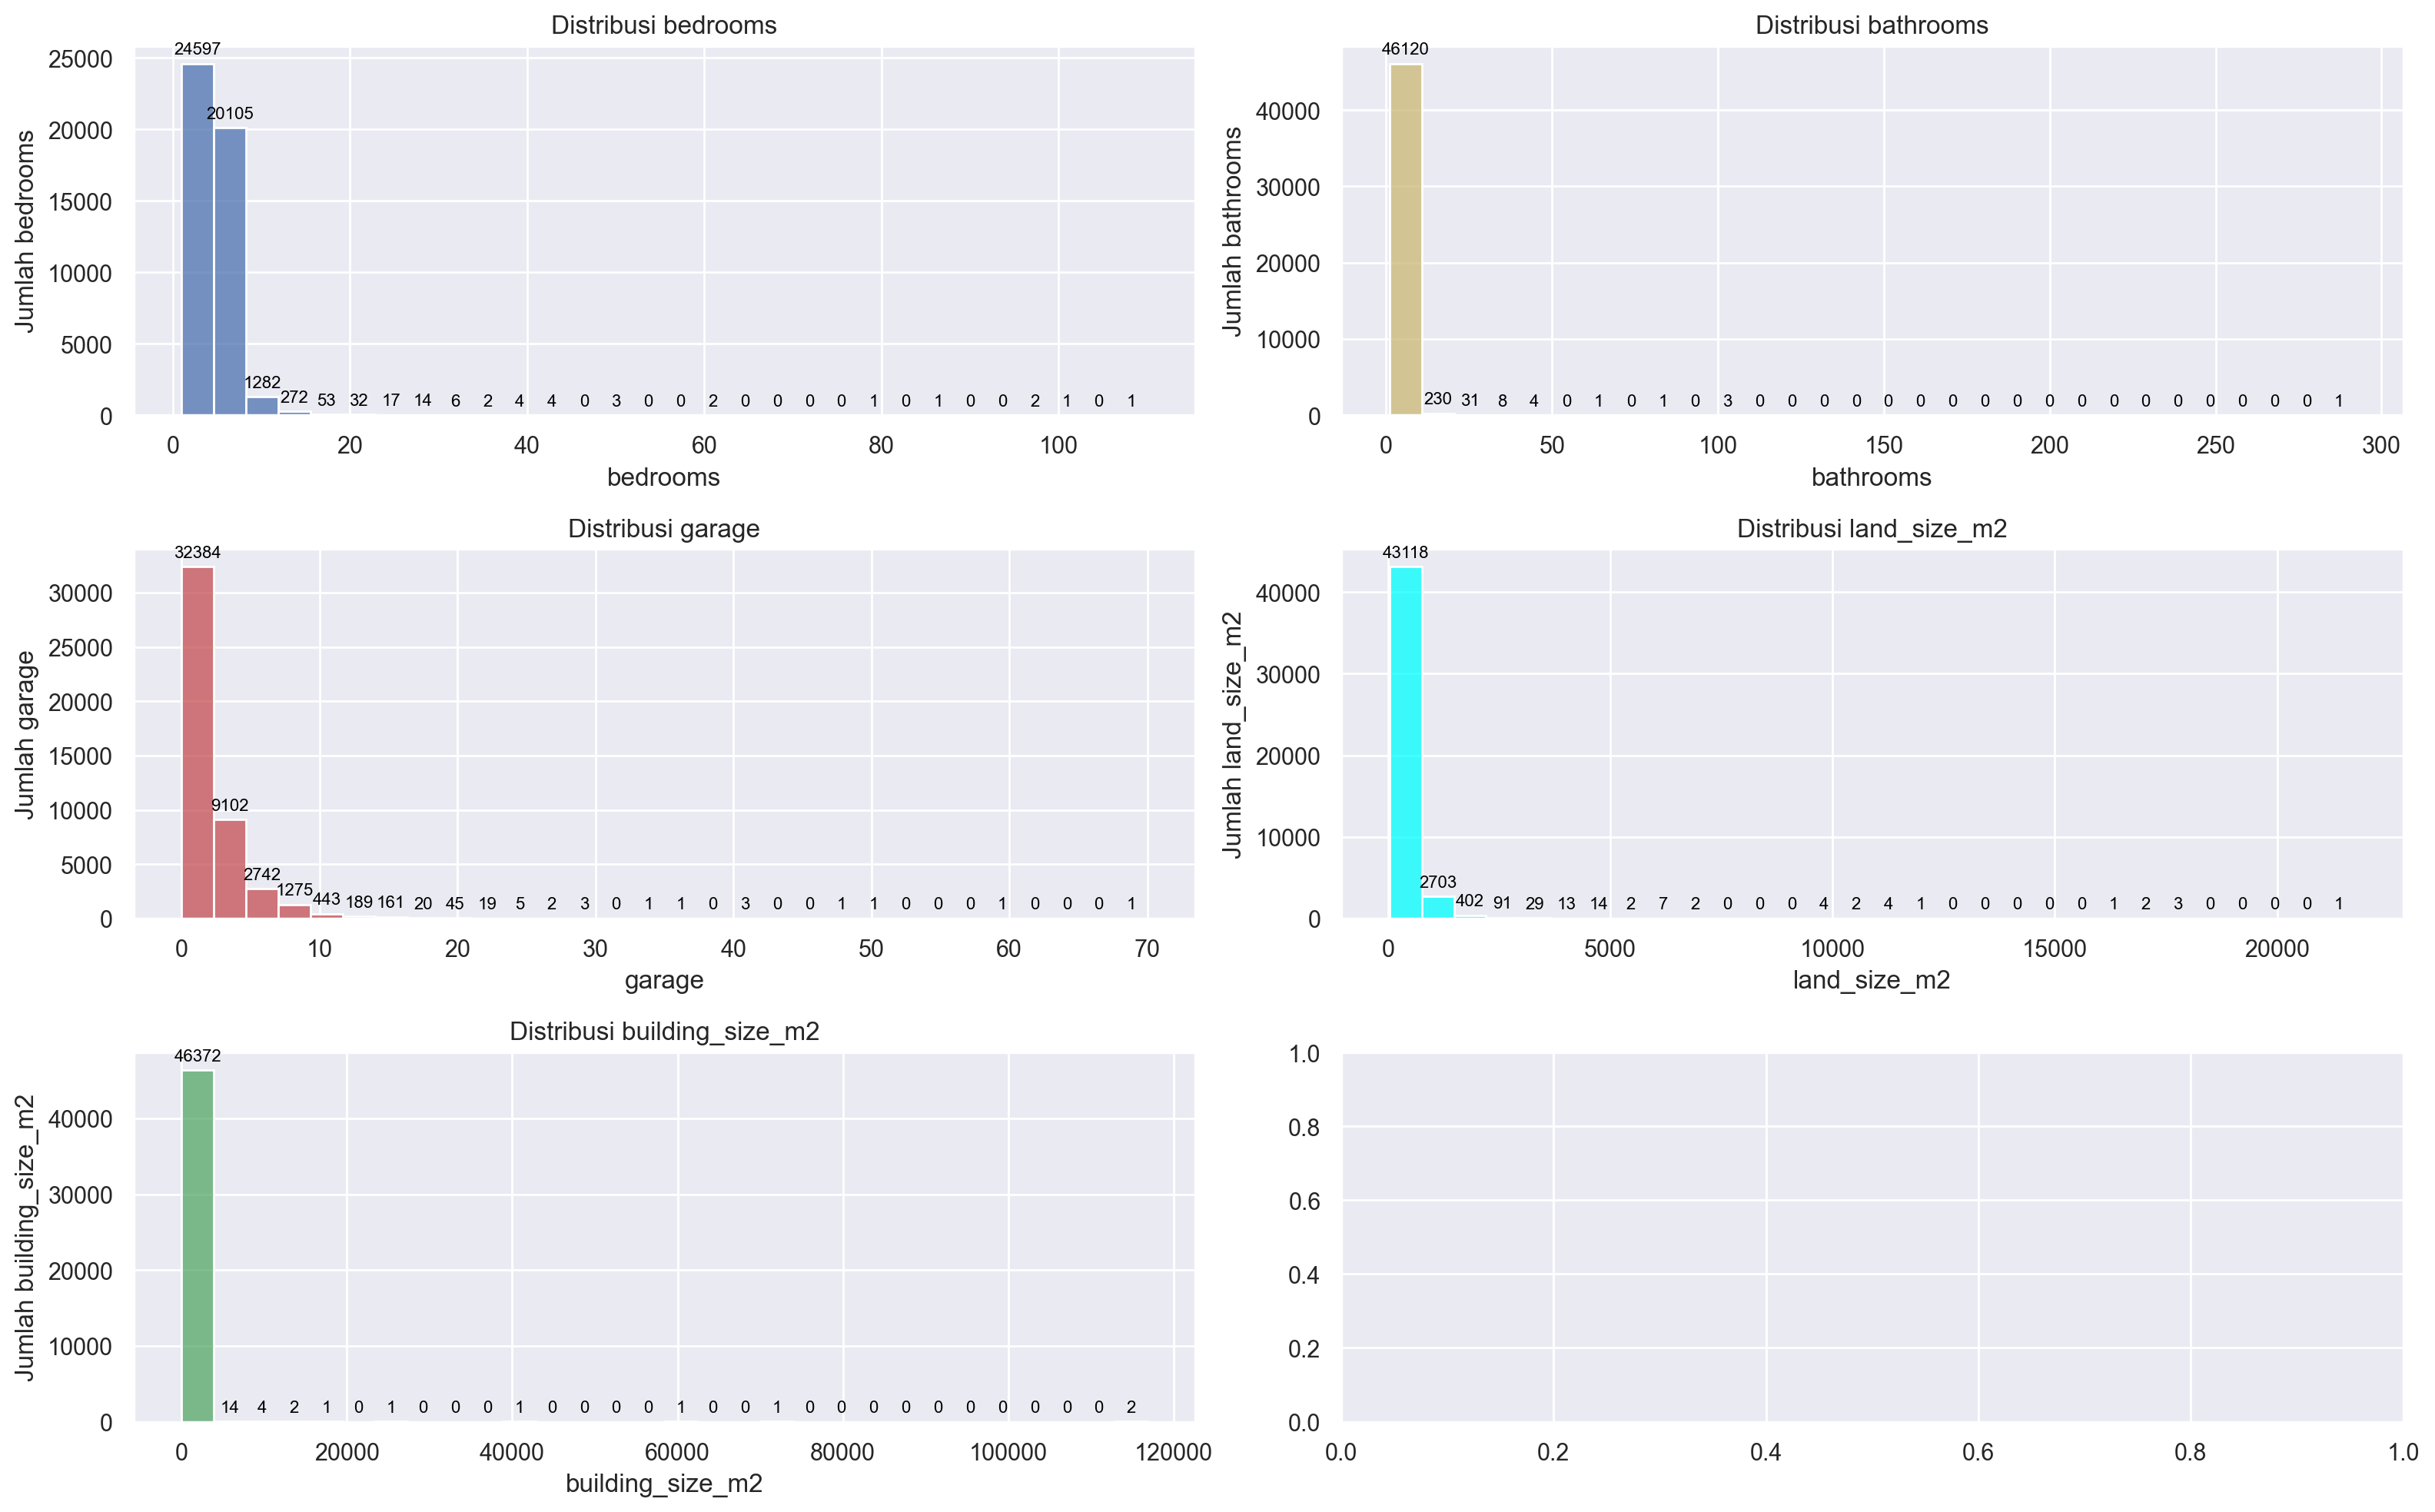

In [41]:
fig , axes = plt.subplots(3,2,figsize=(16,10),dpi=200)
axes = axes.flatten()

columns = ['bedrooms','bathrooms','garage','land_size_m2','building_size_m2']
collor = ['b','y','r','cyan','g']
col = zip(columns,collor)
n = 0

for k,v in col:
    sns.histplot(df[k],bins=30,color=v,ax=axes[n])
    axes[n].bar_label(axes[n].containers[0],fontsize=8,color='black',padding=3)
    axes[n].set_ylabel(f'Jumlah {k}')
    axes[n].set_title(f'Distribusi {k}')
    n = n+1

fig.tight_layout()
plt.show()


In [42]:
df[df['garage'] > 10][['bedrooms', 'bathrooms', 'garage', 'land_size_m2', 'price_idr']]

,bedrooms,bathrooms,garage,land_size_m2,price_idr
29,9.0,6.0,22.0,2360.0,4.800000e+10
54,2.0,2.0,21.0,5555.0,5.500000e+10
86,18.0,20.0,12.0,584.0,4.000000e+10
87,3.0,4.0,14.0,1344.0,2.800000e+10
89,8.0,8.0,15.0,2382.0,8.900000e+10
...,...,...,...,...,...
49784,7.0,6.0,18.0,850.0,8.000000e+10
49794,4.0,4.0,17.0,1400.0,2.500000e+11
49823,4.0,4.0,22.0,1500.0,2.800000e+11
49918,6.0,5.0,12.0,717.0,5.900000e+10


## Memfilter atau memberi batas dan juga transformisasi pada kolom yang dibutuhkan untuk membuat distribusi menjadi normal

In [43]:
# df['bedrooms']  = df['bedrooms'].clip(upper=20)
# df['bathrooms'] = df['bathrooms'].clip(upper=20)
# df['garage']    = df['garage'].clip(upper=20)

df['land_size_log']     = np.log1p(df['land_size_m2'])
df['building_size_log'] = np.log1p(df['building_size_m2'])

## Disribusi atau sebaran setiap kolom setelah melakukan normalisasi dengan cara clip dan log


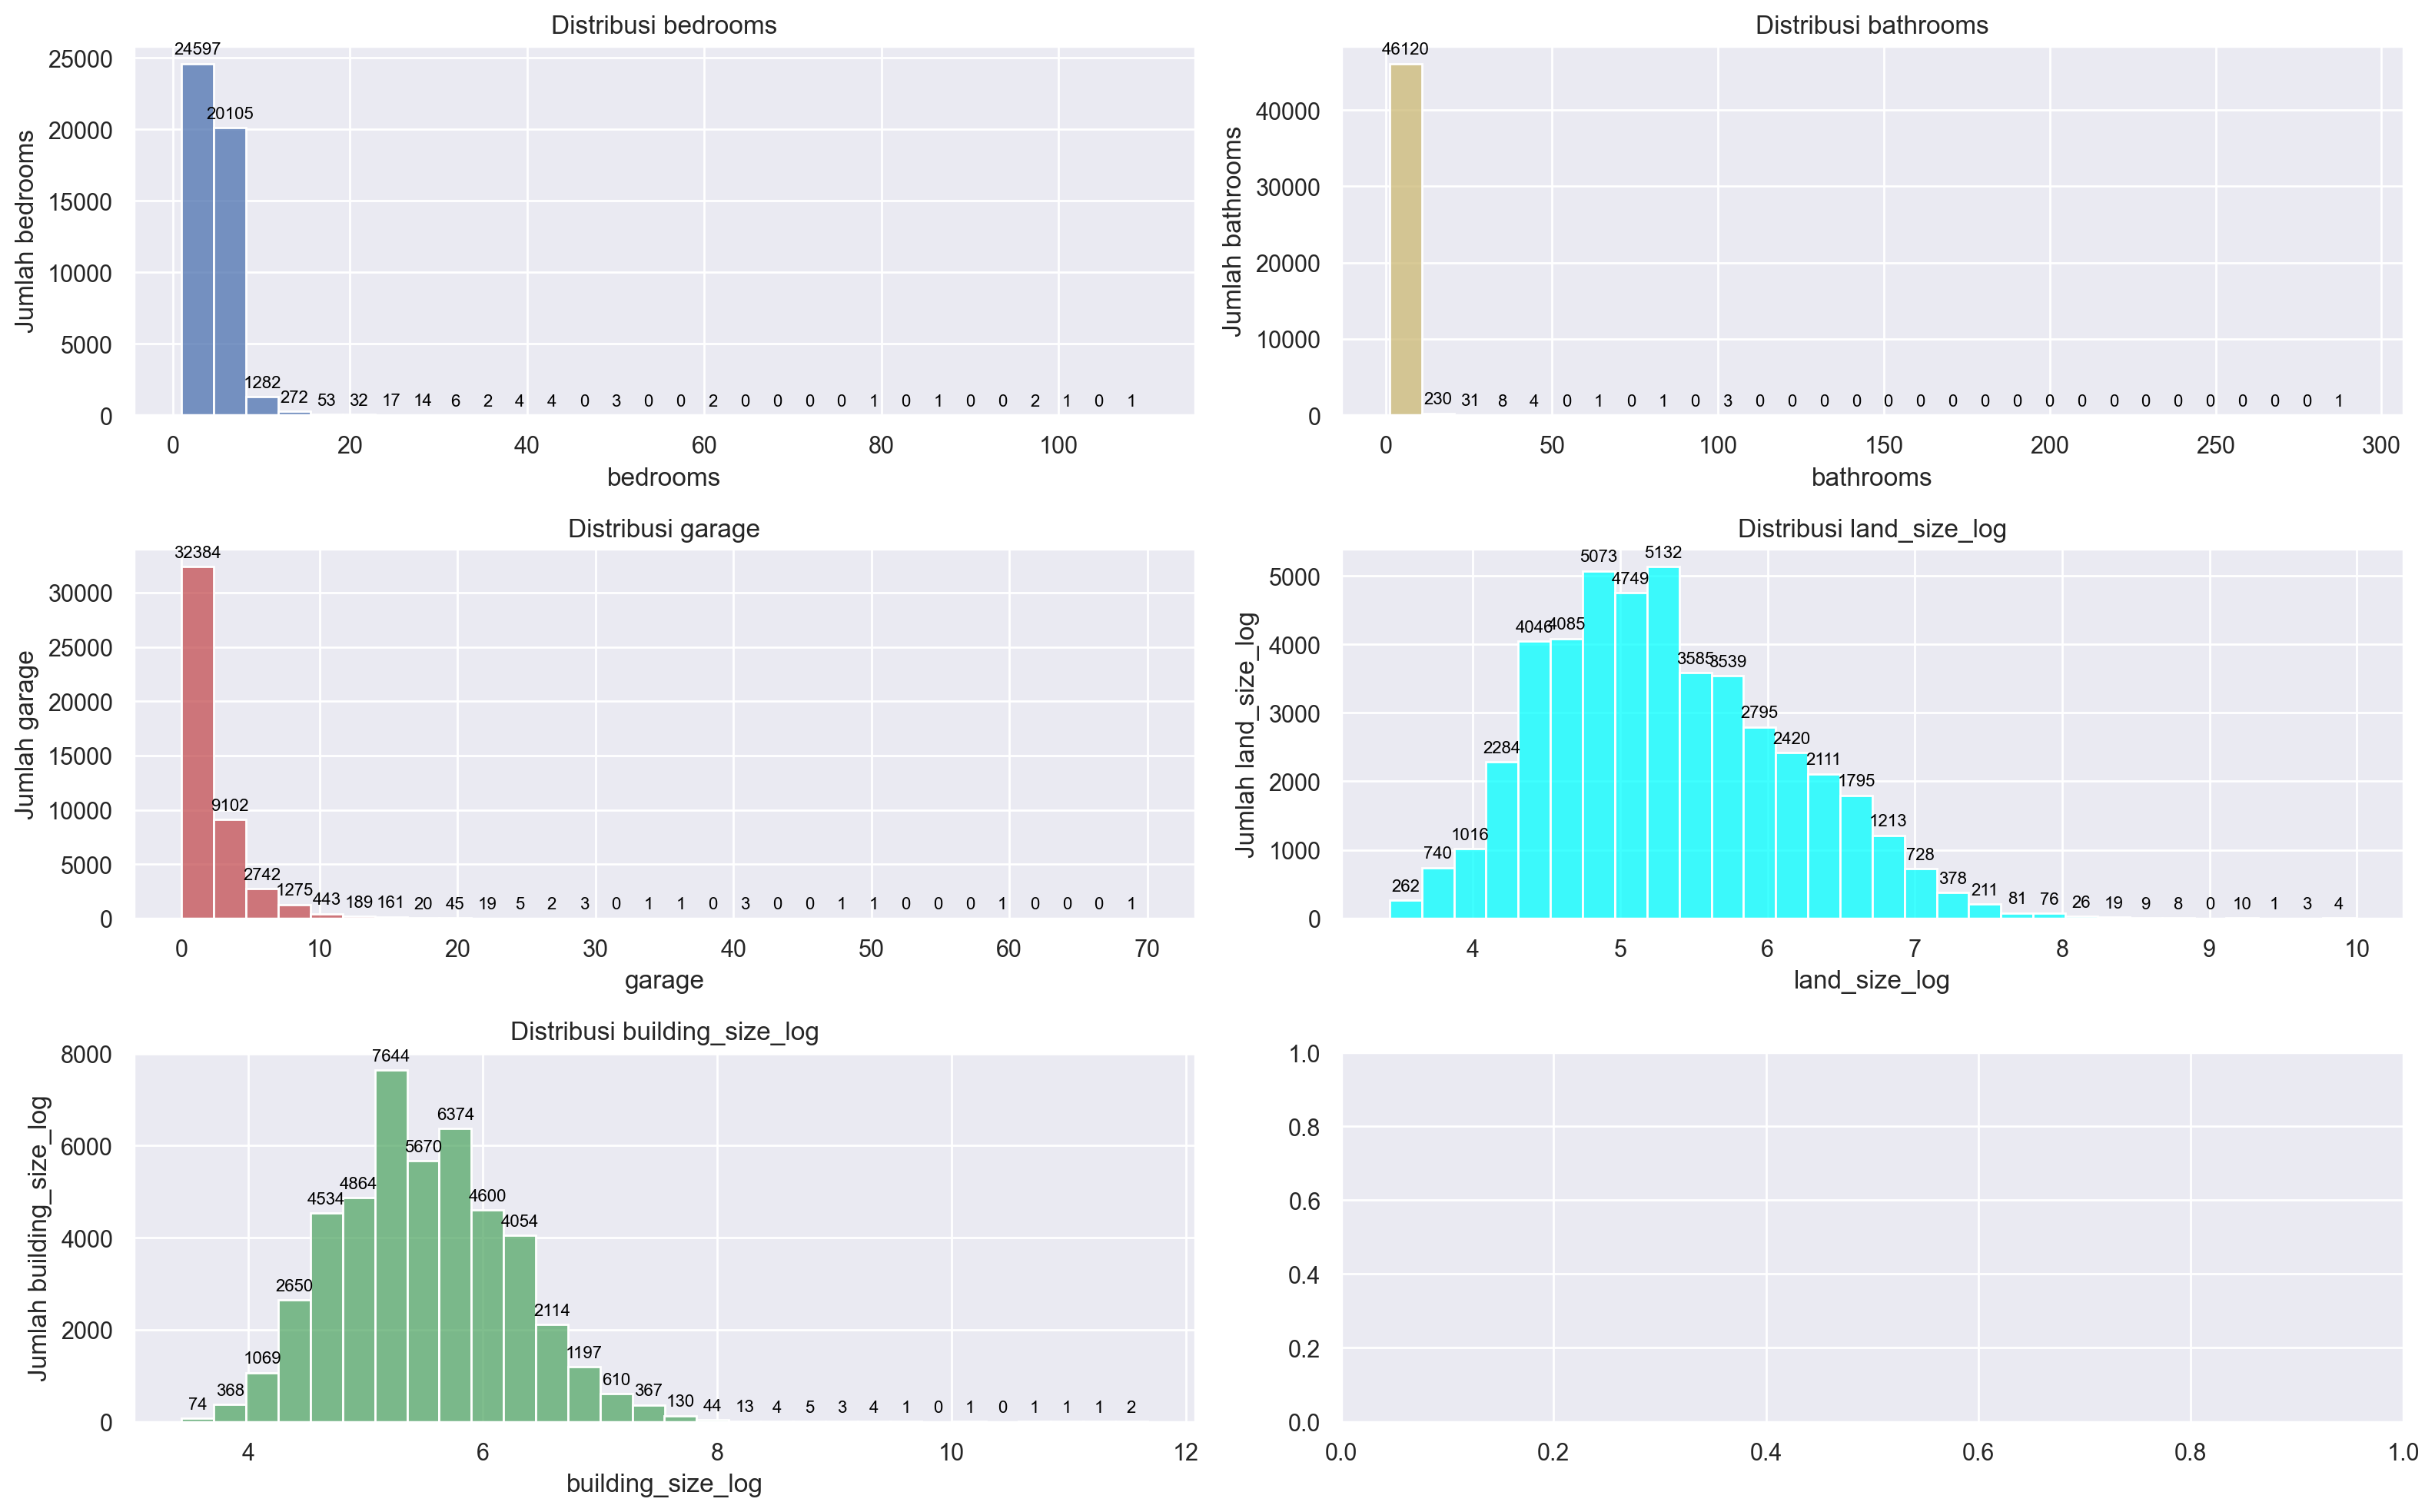

In [44]:
fig , axes = plt.subplots(3,2,figsize=(16,10),dpi=200)
axes = axes.flatten()

columns = ['bedrooms','bathrooms','garage','land_size_log','building_size_log']
collor = ['b','y','r','cyan','g']
col = zip(columns,collor)
n = 0

for k,v in col:
    sns.histplot(df[k],bins=30,color=v,ax=axes[n])
    axes[n].bar_label(axes[n].containers[0],fontsize=8,color='black',padding=3)
    axes[n].set_ylabel(f'Jumlah {k}')
    axes[n].set_title(f'Distribusi {k}')
    n = n+1

fig.tight_layout()
plt.show()

In [45]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,cluster,pool,mrt,tol,furnished,mall,land_size_log,building_size_log
count,4.639900e+04,46399.000000,46399.00000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000,46399.000000
mean,1.124599e+10,4.703463,3.85935,2.272786,298.882347,334.608634,0.066898,0.024850,0.009397,0.028427,0.044117,0.014095,5.312443,5.501149
std,2.114190e+10,2.345814,2.45858,2.427492,427.524860,962.416312,0.249848,0.155669,0.096481,0.166192,0.205358,0.117885,0.829142,0.734182
min,5.000000e+07,1.000000,1.00000,0.000000,30.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.433987,3.433987
25%,2.550000e+09,3.000000,3.00000,1.000000,108.000000,150.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.691348,5.017280
50%,4.700000e+09,4.000000,4.00000,2.000000,180.000000,240.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.198497,5.484797
75%,1.000000e+10,5.000000,5.00000,3.000000,350.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.860786,5.993961
max,6.000000e+11,110.000000,292.00000,70.000000,21754.000000,116799.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.987599,11.668218


In [50]:
low, high = df['price_idr'].quantile([0.01, 0.99])
print(low, high)

# df['price_idr'] = df['price_idr'].clip(low, high)

700000000.0 98000000000.0


In [48]:
df[df['price_idr'] > 100_000_000_000]

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at,cluster,pool,mrt,tol,furnished,mall,land_size_log,building_size_log
94,"dijual rumah di area dekat jl. sriwijaya, kelu...",1.050000e+11,Jakarta Selatan,Senopati,5.0,5.0,6.0,815.0,500.0,2026-04-28T01:54:09.525286+00:00,0,0,0,0,0,0,6.704414,6.216606
138,"rumah mewah premium 2 lantai di pondok indah, ...",2.750000e+11,Jakarta Selatan,Pondok Indah,4.0,5.0,10.0,1585.0,1300.0,2026-04-28T01:56:27.331064+00:00,0,0,0,0,0,0,7.368970,7.170888
148,rajanya area paling private di jakarta| privat...,1.350000e+11,Jakarta Selatan,Pondok Indah,11.0,6.0,5.0,1980.0,800.0,2026-04-28T01:57:02.607039+00:00,0,1,0,0,0,0,7.591357,6.685861
160,rumah lama hook hitung tanah di bukit golf pon...,2.040000e+11,Jakarta Selatan,Pondok Indah,6.0,9.0,13.0,4090.0,1841.0,2026-04-28T01:57:39.026518+00:00,0,0,0,0,0,0,8.316545,7.518607
303,"- ""the golf estate - ultra luxury living in bu...",1.200000e+11,Jakarta Selatan,Pondok Indah,5.0,6.0,8.0,1240.0,1217.0,2026-04-28T02:05:04.694161+00:00,0,0,0,0,0,0,7.123673,7.104965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49799,"dijual 4 unit rumah dalam 1 pintu, mewah dan t...",1.300000e+11,Jakarta Pusat,Menteng,13.0,6.0,10.0,820.0,480.0,2026-05-22T16:04:29.070713+00:00,0,0,0,0,0,0,6.710523,6.175867
49804,dijual rumah mewah kawasan elite menteng,1.100000e+11,Jakarta Pusat,Menteng,6.0,6.0,6.0,952.0,1500.0,2026-05-22T16:04:52.150550+00:00,0,0,0,0,0,0,6.859615,7.313887
49821,rumah siap huni di jakarta pusat fr 17773,2.750000e+11,Jakarta Pusat,Menteng,9.0,8.0,0.0,1515.0,1200.0,2026-05-22T16:06:22.814492+00:00,0,0,0,0,0,0,7.323831,7.090910
49823,dijual rumah modern bagus unfurnished parkiran...,2.800000e+11,Jakarta Pusat,Menteng,4.0,4.0,22.0,1500.0,1500.0,2026-05-22T16:06:33.882798+00:00,0,0,0,0,1,0,7.313887,7.313887


In [51]:
df = pd.get_dummies(df, columns=['city'], dtype=int)

## Menghapus kolom yang tidak butuhkan untuk tahap training model


In [52]:
df = df.drop(columns=['scraped_at','title'])

In [117]:
df['district']

0        Pesanggrahan
1               Tebet
2          Puri Indah
4       Kelapa Gading
5       Kelapa Gading
            ...      
9994          Menteng
9995          Thamrin
9996          Menteng
9998          Menteng
9999       Gondangdia
Name: district, Length: 9265, dtype: str

# Save data yang bersih ke CSV

In [118]:
# df.to_csv('../data/raw/jakarta_properties_processed.csv',index=False)

In [119]:
mapping = {
    'alfa indah': 'kembangan',
    'ampera': 'cilandak',
    'ancol': 'pademangan',
    'angke': 'tambora',
    'bangka': 'mampang prapatan',
    'bendungan hilir': 'tanah abang',
    'bidara cina': 'jatinegara',
    'bintaro': 'pesanggrahan',
    'bojong indah': 'cengkareng',
    'buaran': 'duren sawit',
    'bungur': 'senen',
    'cakung': 'cakung',
    'cempaka mas': 'cempaka putih',
    'cempaka putih': 'cempaka putih',
    'cengkareng': 'cengkareng',
    'cengkareng barat': 'cengkareng',
    'cideng': 'gambir',
    'ciganjur': 'jagakarsa',
    'cijantung': 'pasar rebo',
    'cikini': 'menteng',
    'cilandak': 'cilandak',
    'cilangkap': 'cipayung',
    'cinere': 'cilandak',
    'cipayung': 'cipayung',
    'cipete': 'cilandak',
    'cipinang': 'pulo gadung',
    'ciracas': 'ciracas',
    'citra garden': 'kalideres',
    'citra grand': 'ciracas',
    'condet': 'kramat jati',
    'daan mogot': 'kalideres',
    'duren sawit': 'duren sawit',
    'duren tiga': 'pancoran',
    'duri kepa': 'kebon jeruk',
    'duri kosambi': 'cengkareng',
    'fatmawati': 'cilandak',
    'gajah mada': 'gambir',
    'gambir': 'gambir',
    'glodok': 'taman sari',
    'golf island': 'penjaringan',
    'graha bintaro': 'pesanggrahan',
    'green garden': 'kebon jeruk',
    'green lake city': 'cengkareng',
    'grogol': 'grogol petamburan',
    'grogol petamburan': 'grogol petamburan',
    'gunung sahari': 'kemayoran',
    'intercon': 'kembangan',
    'jakarta garden city': 'cakung',
    'jagakarsa': 'jagakarsa',
    'jatinegara': 'jatinegara',
    'jelambar': 'grogol petamburan',
    'jembatan dua': 'tambora',
    'joglo': 'kembangan',
    'johar baru': 'johar baru',
    'kalibata': 'pancoran',
    'kalideres': 'kalideres',
    'karang anyar': 'sawah besar',
    'kartini': 'sawah besar',
    'kav dki': 'kembangan',
    'kayu putih': 'pulo gadung',
    'kebagusan': 'pasar minggu',
    'kebayoran baru': 'kebayoran baru',
    'kebayoran lama': 'kebayoran lama',
    'kebon jeruk': 'kebon jeruk',
    'kebon kacang': 'tanah abang',
    'kedoya baru': 'kebon jeruk',
    'kedoya garden': 'kebon jeruk',
    'kelapa gading': 'kelapa gading',
    'kemang': 'mampang prapatan',
    'kemanggisan': 'palmerah',
    'kemayoran': 'kemayoran',
    'kembangan': 'kembangan',
    'koja': 'koja',
    'kramat': 'senen',
    'kramat jati': 'kramat jati',
    'kuningan': 'setiabudi',
    'lebak bulus': 'cilandak',
    'lenteng agung': 'jagakarsa',
    'lubang buaya': 'cipayung',
    'makasar': 'makasar',
    'mampang': 'mampang prapatan',
    'mampang prapatan': 'mampang prapatan',
    'mangga besar': 'taman sari',
    'matraman': 'matraman',
    'mega kuningan': 'setiabudi',
    'menteng': 'menteng',
    'menteng atas': 'setiabudi',
    'menteng dalam': 'tebet',
    'meruya': 'kembangan',
    'metland menteng': 'cakung',
    'metland puri': 'cengkareng',
    'muara karang': 'penjaringan',
    'pademangan': 'pademangan',
    'panglima polim': 'kebayoran baru',
    'pancoran': 'pancoran',
    'pantai indah kapuk': 'penjaringan',
    'pantai indah kapuk 2': 'penjaringan',
    'pantai mutiara': 'penjaringan',
    'pasar baru': 'sawah besar',
    'pasar minggu': 'pasar minggu',
    'pasar rebo': 'pasar rebo',
    'pegadungan': 'kalideres',
    'pegangsaan': 'menteng',
    'pejaten': 'pasar minggu',
    'pejompongan': 'tanah abang',
    'penjaringan': 'penjaringan',
    'permata buana': 'kembangan',
    'permata hijau': 'kebayoran lama',
    'percetakan negara': 'johar baru',
    'pesanggrahan': 'pesanggrahan',
    'petukangan': 'pesanggrahan',
    'petojo': 'gambir',
    'pinang ranti': 'makasar',
    'pluit': 'penjaringan',
    'pondok bambu': 'duren sawit',
    'pondok indah': 'kebayoran lama',
    'pondok kelapa': 'duren sawit',
    'pondok kopi': 'duren sawit',
    'pondok labu': 'cilandak',
    'pondok pinang': 'kebayoran lama',
    'pondok ranggon': 'cipayung',
    'pulo gadung': 'pulo gadung',
    'pulomas': 'pulo gadung',
    'puri indah': 'kembangan',
    'puri media': 'kembangan',
    'radio dalam': 'kebayoran baru',
    'rawamangun': 'pulo gadung',
    'salemba': 'senen',
    'sawah besar': 'sawah besar',
    'semanan': 'kalideres',
    'senen': 'senen',
    'sektor 2 - bintaro': 'pesanggrahan',
    'sektor 4 - bintaro': 'pesanggrahan',
    'setiabudi': 'setiabudi',
    'simprug': 'kebayoran lama',
    'slipi': 'palmerah',
    'sukapura': 'cilincing',
    'sunter': 'tanjung priok',
    'sunrise garden': 'grogol petamburan',
    'sumur batu': 'kemayoran',
    'taman kencana': 'kebon jeruk',
    'taman meruya': 'kembangan',
    'taman palem': 'cengkareng',
    'taman ratu': 'kebon jeruk',
    'taman sari': 'taman sari',
    'taman surya': 'cengkareng',
    'tambora': 'tambora',
    'tanah abang': 'tanah abang',
    'tanjung duren': 'grogol petamburan',
    'tanjung duren selatan': 'grogol petamburan',
    'tanjung duren utara': 'grogol petamburan',
    'tanjung priok': 'tanjung priok',
    'tb simatupang': 'pasar minggu',
    'tebet': 'tebet',
    'teluk gong': 'penjaringan',
    'thamrin': 'menteng',
    'tomang': 'grogol petamburan',
    'utan kayu': 'matraman'
}

In [120]:
df['sub_district'] = df['district'].copy()

In [121]:
df['district'].value_counts()

district
Kelapa Gading         550
Cempaka Putih         445
Menteng               415
Pantai Indah Kapuk    363
Sunter                341
                     ... 
Kampung Ambon           1
Hasyim Ashari           1
Harmoni                 1
Samanhudi               1
Hayam Wuruk             1
Name: count, Length: 246, dtype: int64

In [122]:
df['district'] = df['district'].str.lower()
df['district'] = df['district'].map(mapping)